# INFO-6147-(01)-26W Deep Learning with Pytorch

## Project: Flavor Bridge 

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 30th, 2026

**GitHub:"** https://github.com/virwang/Fanshawe_DL_Pytorch26W.git

**Description:**

This project is aim to allow user upload the photos of food and describe what the food tastes like. It will be helpful when traveling or when people wants to try international food, but not having a person to explain to you what that is.
Here comes this AI project, to assist people on observing new foods.

## Setup Environment

In [1]:
!pip install datasets gradio streamlit groq pyngrok

# dlownload Cloudflare tunnle tool
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 143.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 166.0 MB/s eta 0:00:00
--2026-04-11 20:15:37--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb [following]
--2026-04-11 20:15:37--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/ec689fe1-d727-4ebd-bbc3-5967730ab5

## Import Libs

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.datasets import Food101
from torch.utils.data import Dataset, Subset,DataLoader, random_split,Subset
from sklearn.model_selection import train_test_split

from datasets import load_dataset

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import io
from tqdm import tqdm

from google.colab import userdata,runtime,drive # Store the API via Colab Secret
import zipfile
import os

#Allow system automatically selects the fastest convolution algorithm for my ResNet50 architecture.
torch.backends.cudnn.benchmark = True

## Check Device

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Define Path Parameters


In [4]:
# 1. Define absolute paths (ensuring no variable name confusion)

# Make sure SOURCE_DRIVE_ZIP matches the file location in your Drive sidebar

SOURCE_DRIVE_ZIP = "/content/drive/MyDrive/food-101.tar.gz"

TARGET_LOCAL_ROOT = "/content/food101_local"

## Connect to Google Drive


In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


## Data Preparation & Curation

### Define Food Types for subset

In [7]:
select_food_list = sorted( [
     # --- Asia ---
    'bibimbap', 'gyoza', 'sashimi', 'pad_thai', 'pho',
    'miso_soup', 'edamame', 'spring_rolls', 'sushi', 'dumplings',
    'hummus', 'falafel', 'baklava', 'chicken_curry', 'fried_rice',

    # --- Lattino ---
    'tacos', 'guacamole', 'ceviche', 'nachos',

    # --- Classic ---
    'pizza', 'hamburger', 'hot_dog', 'steak', 'french_fries',
    'grilled_salmon', 'spaghetti_bolognese', 'lasagna', 'club_sandwich',

    # --- Hot in Social Media ---
    'tiramisu', 'cheesecake', 'macarons', 'donuts', 'waffles',
    'pancakes', 'ice_cream', 'apple_pie', 'strawberry_shortcake',

    # --- seafoods ---
    'mussels', 'oysters',
     # -- Europe --
     'escargots'

]
)

# Create Mapping dictionary
label_to_name = {i: name for i, name in enumerate(select_food_list)}
print(label_to_name)

class_to_idx = {cls_name: i for i, cls_name in enumerate(select_food_list)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

select = [
    {"Class Index": class_idx, "Class Name": class_name }
    for idx, (class_name, class_idx) in enumerate(class_to_idx.items())
]

df_select = pd.DataFrame(select)
display(df_select)

{0: 'apple_pie', 1: 'baklava', 2: 'bibimbap', 3: 'ceviche', 4: 'cheesecake', 5: 'chicken_curry', 6: 'club_sandwich', 7: 'donuts', 8: 'dumplings', 9: 'edamame', 10: 'escargots', 11: 'falafel', 12: 'french_fries', 13: 'fried_rice', 14: 'grilled_salmon', 15: 'guacamole', 16: 'gyoza', 17: 'hamburger', 18: 'hot_dog', 19: 'hummus', 20: 'ice_cream', 21: 'lasagna', 22: 'macarons', 23: 'miso_soup', 24: 'mussels', 25: 'nachos', 26: 'oysters', 27: 'pad_thai', 28: 'pancakes', 29: 'pho', 30: 'pizza', 31: 'sashimi', 32: 'spaghetti_bolognese', 33: 'spring_rolls', 34: 'steak', 35: 'strawberry_shortcake', 36: 'sushi', 37: 'tacos', 38: 'tiramisu', 39: 'waffles'}


,Class Index,Class Name
0,0,apple_pie
1,1,baklava
2,2,bibimbap
3,3,ceviche
4,4,cheesecake
5,5,chicken_curry
6,6,club_sandwich
7,7,donuts
8,8,dumplings
9,9,edamame


#### Create Filter Class

In [8]:
class FilteredFood101(Dataset):
    def __init__(self, dataset, selected_classes, transform=None):
        self.dataset = dataset
        self.transform = transform

        self.selected_classes = selected_classes
        self.class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}

        self.filtered_indices = []

        for i in range(len(dataset)):
            label = dataset._labels[i]
            class_name = dataset.classes[label]

            if class_name in self.selected_classes:
                self.filtered_indices.append(i)

    def __len__(self):
        return len(self.filtered_indices)

    def __getitem__(self, idx):
        real_idx = self.filtered_indices[idx]
        img, label = self.dataset[real_idx]

        class_name = self.dataset.classes[label]
        new_label = self.class_to_idx[class_name]  # ⭐ rebuild label

        if self.transform:
            img = self.transform(img)

        return img, new_label

#### Extract from Google Drive to Colab Drive

Since the Food101 dataset is quite large (5GB), I pre-uploaded the compressed file to Google Drive to optimize data loading. At the start of each session, the dataset is extracted directly to the Colab local runtime to ensure high-speed I/O during training.

#### Clean up the old data to avoid "Ghost Folders"

In [9]:
# 1. Clean up the old data to avoid "Ghost Folders"
!rm -rf /content/food101_local
os.makedirs(TARGET_LOCAL_ROOT, exist_ok=True)

In [10]:
# 2. Define exactly what to extract
# We need the images for your 40 classes AND the meta folder
extract_targets = [f"food-101/images/{food}" for food in select_food_list]
extract_targets.append("food-101/meta")
targets_str = " ".join(extract_targets)

# 3. Execute extraction with the TARGETS specified
print(f"🚀 Extracting ONLY {len(select_food_list)} categories...")
!tar -xzf "{SOURCE_DRIVE_ZIP}" -C "{TARGET_LOCAL_ROOT}" {targets_str}

# 4. Final Validation
images_path = os.path.join(TARGET_LOCAL_ROOT, "food-101/images")
actual_folders = os.listdir(images_path)
print(f"✅ Extraction successful! Total folders: {len(actual_folders)}")

if len(actual_folders) != 40:
    print(f"⚠️ Warning: Expected 40 but found {len(actual_folders)}")

🚀 Extracting ONLY 40 categories...
✅ Extraction successful! Total folders: 40


### Load Dataset (Selected Food list) - Splitting & Transformation

#### Set up transformer

In [11]:
# Transformer

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#### Data Prepare

In [12]:
# Load the "Clean" dataset using ImageFolder
# This automatically remaps the 40 folders to labels 0-39
full_dataset = datasets.ImageFolder(root=images_path)

# Verify class count and mapping
print(f"✅ Total classes detected: {len(full_dataset.classes)}")
print(f"✅ Sample Mapping (Class to Index): {dict(list(full_dataset.class_to_idx.items())[:3])}")

# Perform Stratified Split (80% Train, 20% Temporary for Val/Test)
# We use full_dataset.targets which are already in the 0-39 range
indices = np.arange(len(full_dataset))
labels = full_dataset.targets

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=full_dataset.targets,
    random_state=42
)

# Split the 20% temp set into Validation and Test (50/50 of the 20%, i.e., 10% each)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=[full_dataset.targets[i] for i in temp_idx],
    random_state=42
)

# Create Subset objects with specific transforms
# Create one dataset for training (with augmentations)
train_data = datasets.ImageFolder(root=images_path, transform=train_transform)

# Create one dataset for validation/testing (clean resizing only)
eval_data = datasets.ImageFolder(root=images_path, transform=test_transform)

# Define your subsets correctly
train_subset = Subset(train_data, train_idx)
val_subset   = Subset(eval_data, val_idx)
test_subset  = Subset(eval_data, test_idx)

# --- STEP 3: Final Summary ---
print(f"📊 Final Data Preprocessing Complete:")
print(f"Total Classes: {len(train_data.classes)}")
print(f"Training size: {len(train_subset)} (Augmented)")
print(f"Validation size: {len(val_subset)} (Clean)")
print(f"Test size: {len(test_subset)} (Clean)")

✅ Total classes detected: 40
✅ Sample Mapping (Class to Index): {'apple_pie': 0, 'baklava': 1, 'bibimbap': 2}
📊 Final Data Preprocessing Complete:
Total Classes: 40
Training size: 32000 (Augmented)
Validation size: 4000 (Clean)
Test size: 4000 (Clean)


#### Validate the Selected Food Type

Since the selected_food_type is a self degined labels, this section is to confirm all the labels are in the raw data

In [13]:
# 1. Get the classes discovered by ImageFolder (already sorted by PyTorch)
extracted_classes = full_dataset.classes

# 2. Get your original list sorted alphabetically (to match PyTorch's logic)
sorted_original_list = sorted(select_food_list)

# 3. Verification Logic
is_match = (extracted_classes == sorted_original_list)

print(f"--- Synchronization Check ---")
print(f"PyTorch Classes: {len(extracted_classes)}")
print(f"Your Original List: {len(sorted_original_list)}")
print(f"Perfect Match? {is_match}")

if not is_match:
    missing_in_disk = set(sorted_original_list) - set(extracted_classes)
    extra_on_disk = set(extracted_classes) - set(sorted_original_list)
    if missing_in_disk: print(f"❌ Missing on disk: {missing_in_disk}")
    if extra_on_disk: print(f"⚠️ Extra on disk: {extra_on_disk}")
else:
    print("✅ Success: The labels 0-39 match your list perfectly.")

--- Synchronization Check ---
PyTorch Classes: 40
Your Original List: 40
Perfect Match? True
✅ Success: The labels 0-39 match your list perfectly.


#### List the extracted labels

In [15]:
!ls /content/food101_local/food-101/images

apple_pie      dumplings       gyoza	  mussels   spaghetti_bolognese
baklava        edamame	       hamburger  nachos    spring_rolls
bibimbap       escargots       hot_dog	  oysters   steak
ceviche        falafel	       hummus	  pad_thai  strawberry_shortcake
cheesecake     french_fries    ice_cream  pancakes  sushi
chicken_curry  fried_rice      lasagna	  pho	    tacos
club_sandwich  grilled_salmon  macarons   pizza     tiramisu
donuts	       guacamole       miso_soup  sashimi   waffles


## Data Pipeline Infrastructure

#### DataLoader Setup

#### Hyper Parameters

In [16]:
EPOCHS=50
BATCH_SIZE = 256
LEARNING_RATE=0.0001
NUM_WORKERS= 12
PATIENCE = 10 # early stop

#### DataLoader

In [17]:
train_loader = DataLoader(train_subset,batch_size=BATCH_SIZE,shuffle=True,pin_memory=True, num_workers=NUM_WORKERS)
# train_loader = DataLoader(train_subset,
#  = DataLoader(train_subset, batch_size=BATCH_SIZE,shuffle=True, num_workers=NUM_WORKERS,pin_memory=True)

test_loader = DataLoader(test_subset,                        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,pin_memory=True)

num_classes = len(train_subset.indices)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Build the model

In [18]:
# number of extracted classes
num_classes = len(extracted_classes)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# model.fc = nn.Sequential(
#     nn.Linear(model.fc.in_features, 512),
#     nn.BatchNorm1d(512),
#     nn.ReLU(),                # activate param
#     nn.Dropout(0.3),          # drop off 30%
#     nn.Linear(512, num_classes) # output classes
# )

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024), # larger to 1024
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.3),           # prevernt overfitting
    nn.Linear(1024, 512),      # add layer
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Linear(512, num_classes)         #final classes
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE,weight_decay=1e-4)

# Lower the learning rate once the loss starts to plateau.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 249MB/s]


## Define the Model

In [19]:
class FoodClassifier:
    def __init__(self, model, train_loader, test_loader, criterion, optimizer, device, patience=PATIENCE,scheduler=None):
        self.model = model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.scheduler = scheduler

        # self.scaler = torch.cuda.amp.GradScaler(self.device)
        self.scaler = torch.cuda.amp.GradScaler()

        # History
        self.history = {
            'train_loss': [], 'train_acc': [],
            'test_loss': [], 'test_acc': [],
            'test_f1': [],'lr': []
        }

    def train_epoch(self):
      self.model.train()
      running_loss, correct, total = 0.0, 0, 0
      pbar = tqdm(self.train_loader, desc="[Train]", leave=False)

      for images, labels in pbar:
          images, labels = images.to(self.device), labels.to(self.device)
          self.optimizer.zero_grad()

          # 1. Use autocast for forward pass (automatically switches between float16 and float32)
          with torch.cuda.amp.autocast():
              outputs = self.model(images)
              loss = self.criterion(outputs, labels)

          # 2. Use GradScaler for backpropagation and optimization
          self.scaler.scale(loss).backward()
          self.scaler.step(self.optimizer)
          self.scaler.update()

          running_loss += loss.item()
          _, predicted = outputs.max(1)
          total += labels.size(0)
          correct += predicted.eq(labels).sum().item()

      return running_loss / len(self.train_loader), 100. * correct / total

    def validate(self):
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
          with torch.cuda.amp.autocast():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                # record F1
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = running_loss / len(self.test_loader)
        acc = 100. * correct / total
        f1 = f1_score(all_labels, all_preds, average='macro')
        return avg_loss, acc, f1

    def run_training(self, num_epochs, save_path):
        print(f"Training started (ResNet-50 / 40 Classes)")
        print(f"Save destination: {save_path}\n")

        for epoch in range(num_epochs):
            t_loss, t_acc = self.train_epoch()
            v_loss, v_acc, v_f1 = self.validate()

            # update Scheduler
            if self.scheduler:
              # if is ReduceLROnPlateau，input v_loss
              if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                  self.scheduler.step(v_loss)
              else:
                  self.scheduler.step()

            # record current learning rate
            current_lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['train_acc'].append(t_acc)
            self.history['test_loss'].append(v_loss)
            self.history['test_acc'].append(v_acc)
            self.history['test_f1'].append(v_f1)
            self.history['lr'].append(current_lr)

            print(f"Epoch {epoch+1:02d}/{num_epochs} | "
                  f"Train Acc: {t_acc:.2f}% | Test Acc: {v_acc:.2f}% | "
                  f"F1: {v_f1:.4f}")

            # --- Early Stopping Logic ---
            if v_loss < self.best_loss:
                self.best_loss = v_loss
                self.counter = 0
                torch.save(self.model.state_dict(), save_path)
                print(f"New best model saved! (Loss: {v_loss:.4f})")
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}.")
                    break

        print(f"\n Training complete. Loading best weights for final data collection...")

        # Training complete; load the most powerful version to output the final prediction results.
        self.model.load_state_dict(torch.load(save_path))
        final_y_true, final_y_pred = self._get_final_predictions()

        return self.history, final_y_true, final_y_pred

    def _get_final_predictions(self):
        self.model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                _, predicted = outputs.max(1)
                y_true.extend(labels.numpy())
                y_pred.extend(predicted.cpu().numpy())
        return y_true, y_pred

## Model Evaluation

Evaluate the model performance including metrics, confusion matrix, detailed report, and visual inference.

In [54]:
class ModelEvaluator:
    """
    Evaluate the model performance including metrics, confusion matrix,
    detailed report, and visual inference.
    """
    def __init__(self, history, y_true, y_pred, class_names, model=None, test_loader=None, device=None):
        self.history = history
        self.y_true = np.array(y_true)
        self.y_pred = np.array(y_pred)
        self.class_names = class_names

        # add attribute for visualize
        self.model = model
        self.test_loader = test_loader
        self.device = device

    def plot_accuracy(self):
        """Show Accuracy """
        plt.figure(figsize=(10, 6))
        epochs = range(1, len(self.history['train_loss']) + 1)
        plt.plot(epochs, self.history['train_acc'], 'g-o', label='Train Acc', markersize=4)
        plt.plot(epochs, self.history['test_acc'], 'm-s', label='Test Acc', markersize=4)

        plt.title('Accuracy Trend: Training vs Testing', fontsize=15, pad=15)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

    def plot_loss(self):
        """show Loss"""
        plt.figure(figsize=(10, 6))
        epochs = range(1, len(self.history['train_loss']) + 1)
        plt.plot(epochs, self.history['train_loss'], 'b-o', label='Train Loss', markersize=4)
        plt.plot(epochs, self.history['test_loss'], 'r-s', label='Test Loss', markersize=4)

        plt.title('Loss Convergence: Training vs Testing', fontsize=15, pad=15)
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss Value', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

    def plot_learning_rate(self):
        """show Learning Rate """
        if 'lr' in self.history and len(self.history['lr']) > 0:
            plt.figure(figsize=(10, 6))
            epochs = range(1, len(self.history['lr']) + 1)
            plt.plot(epochs, self.history['lr'], 'k-x', label='LR')
            # using log to significant the decay
            plt.yscale('log')
            plt.title('Learning Rate Schedule', fontsize=15, pad=15)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('LR (Log Scale)', fontsize=12)
            plt.grid(True, which="both", ls="-", alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print("No Learning Rate data recorded in history.")

    def plot_f1_score(self):
        """show F1-Score """
        if 'test_f1' in self.history and len(self.history['test_f1']) > 0:
            plt.figure(figsize=(10, 6))
            epochs = range(1, len(self.history['test_f1']) + 1)
            plt.plot(epochs, self.history['test_f1'], 'c-^', label='Test F1 (Macro)')

            plt.title('Model Balance: F1-Score Trend', fontsize=15, pad=15)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('F1 Score', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend()
            plt.tight_layout()
            plt.show()

    def plot_confusion_matrix(self, figsize=(18, 14)):
        """2. Confusion Matrix"""
        # cm = confusion_matrix(self.y_true, self.y_pred)
        # plt.figure(figsize=figsize)
        # sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', annot_kws={'size':8},
        #             xticklabels=self.class_names,
        #             yticklabels=self.class_names)
        # plt.title('Confusion Matrix: Food-40 Classification', fontsize=16)
        # plt.ylabel('Actual Food Type')
        # plt.xlabel('Predicted Food Type')
        # plt.xticks(rotation=45, ha='right')
        # plt.show()
        report = classification_report(self.y_true, self.y_pred,
                                        target_names=self.class_names,
                                        output_dict=True, zero_division=0)


        # get F1-score for each class (remove marco/weight avg)
        class_stats = {k: v['f1-score'] for k, v in report.items() if k in self.class_names}

        # name for top 5 and worst 5
        sorted_classes = sorted(class_stats.items(), key=lambda x: x[1], reverse=True)
        top_5 = [x[0] for x in sorted_classes[:5]]
        worst_5 = [x[0] for x in sorted_classes[-5:]]
        selected_classes = top_5 + worst_5

        # get category indexes via raw class_names
        indices = [list(self.class_names).index(cls) for cls in selected_classes]

        # 5. Slicing
        cm = confusion_matrix(self.y_true, self.y_pred)
        filtered_cm = cm[np.ix_(indices, indices)]

        # graphing
        plt.figure(figsize=figsize)
        sns.heatmap(filtered_cm, annot=True, fmt='d', cmap='YlGnBu',
                    xticklabels=selected_classes,
                    yticklabels=selected_classes,
                    annot_kws={'size': 10})

        plt.title('Confusion Matrix: Top 5 & Worst 5 Categories', fontsize=16)
        plt.ylabel('Actual Food Type', fontsize=12)
        plt.xlabel('Predicted Food Type', fontsize=12)
        plt.xticks(rotation=45, ha='right')


        # add line to distinguish Top and worst
        plt.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5)
        plt.axvline(x=5, color='red', linestyle='--', linewidth=2, alpha=0.5)
        plt.text(0.5, 4.8, 'Top 5', color='green', fontweight='bold')
        plt.text(5.5, 9.8, 'Worst 5', color='red', fontweight='bold')

        plt.tight_layout()
        plt.show()


    def print_detailed_analysis(self):
        """3. Classification Report & Worst Classes"""
        print("\n" + "="*60)
        print("DETAILED CLASSIFICATION PERFORMANCE")
        print("="*60)
        all_labels = list(range(len(self.class_names)))

        report = classification_report(self.y_true, self.y_pred,
                                        target_names=self.class_names,
                                        labels=all_labels,
                                        output_dict=True, zero_division=0)

        class_stats = {k: v for k, v in report.items() if k in self.class_names}
        worst_5 = sorted(class_stats.items(), key=lambda x: x[1]['f1-score'])[:5]

        print(f"{'Food Class':<20} | {'F1-Score':<10} | {'Precision':<10} | {'Recall':<10}")
        print("-" * 60)
        for name, stats in worst_5:
            print(f"{name:<20} | {stats['f1-score']:.4f} | {stats['precision']:.4f} | {stats['recall']:.4f}")

        final_f1 = f1_score(self.y_true, self.y_pred, average='macro')
        print(f"\nFinal Macro F1-Score: {final_f1:.4f}")

    def visualize_predictions(self, num_images=15):
        """4. Visual Inference (True vs Pred)"""
        if self.model is None or self.test_loader is None:
            print("Error: Model and test_loader must be provided for visualization.")
            return

        self.model.eval()
        all_images, all_labels, all_preds = [], [], []

        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                with torch.amp.autocast('cuda'):
                    outputs = self.model(images)
                    _, preds = torch.max(outputs, 1)

                all_images.extend(images.cpu())
                all_labels.extend(labels.cpu())
                all_preds.extend(preds.cpu())
                if len(all_images) >= num_images: break

        plt.figure(figsize=(20, 12))
        plt.suptitle("Final Inference: Sample Predictions", fontsize=20)

        for i in range(num_images):
            ax = plt.subplot(3, 5, i + 1)
            ax.axis('off')

            # De-normalize
            img = all_images[i].numpy().transpose((1, 2, 0))
            mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            true_name, pred_name = self.class_names[all_labels[i]], self.class_names[all_preds[i]]
            color = 'green' if all_labels[i] == all_preds[i] else 'red'

            plt.imshow(img)
            ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=color, fontsize=10, fontweight='bold')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

## Start training

In [21]:
trainer = FoodClassifier(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    scheduler=scheduler
)

my_history,my_y_true, my_y_pred = trainer.run_training(num_epochs=EPOCHS,save_path="/content/drive/MyDrive/food_best.pth")

/tmp/ipykernel_2740/2225463610.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


Training started (ResNet-50 / 40 Classes)
Save destination: /content/drive/MyDrive/food_best.pth



[Train]:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_2740/2225463610.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2740/2225463610.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/50 | Train Acc: 49.83% | Test Acc: 76.20% | F1: 0.7574
New best model saved! (Loss: 1.0289)


[Train]:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_2740/2225463610.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2740/2225463610.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

[Train]:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_2740/2225463610.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2740/2225463610.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 22/50 | Train Acc: 94.55% | Test Acc: 89.62% | F1: 0.8963


[Train]:   0%|          | 0/125 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_2740/2225463610.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_2740/2225463610.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 23/50 | Train Acc: 94.52% | Test Acc: 89.65% | F1: 0.8966
Early stopping at epoch 23.

 Training complete. Loading best weights for final data collection...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Show Evaluation

In [55]:
from collections import Counter

test_counts = Counter(my_y_true)
print(f"Classes shown in train:{test_counts}")

#Print True Lables
print(f"True Labels:{my_y_true[:10]}")

evaluation = ModelEvaluator(
    history=my_history,
    y_true=my_y_true,
    y_pred=my_y_pred,
    class_names= train_data.classes,
    model=trainer.model,
    test_loader=test_loader,
    device=DEVICE
)

Classes shown in train:Counter({np.int64(20): 100, np.int64(23): 100, np.int64(38): 100, np.int64(11): 100, np.int64(1): 100, np.int64(8): 100, np.int64(17): 100, np.int64(34): 100, np.int64(14): 100, np.int64(26): 100, np.int64(10): 100, np.int64(30): 100, np.int64(39): 100, np.int64(25): 100, np.int64(16): 100, np.int64(0): 100, np.int64(29): 100, np.int64(4): 100, np.int64(28): 100, np.int64(21): 100, np.int64(12): 100, np.int64(3): 100, np.int64(22): 100, np.int64(27): 100, np.int64(31): 100, np.int64(2): 100, np.int64(19): 100, np.int64(15): 100, np.int64(33): 100, np.int64(36): 100, np.int64(7): 100, np.int64(32): 100, np.int64(18): 100, np.int64(6): 100, np.int64(35): 100, np.int64(13): 100, np.int64(37): 100, np.int64(5): 100, np.int64(9): 100, np.int64(24): 100})
True Labels:[np.int64(20), np.int64(23), np.int64(38), np.int64(11), np.int64(1), np.int64(8), np.int64(1), np.int64(38), np.int64(17), np.int64(34)]


#### Comprehensive Metrics


##### Accuracy

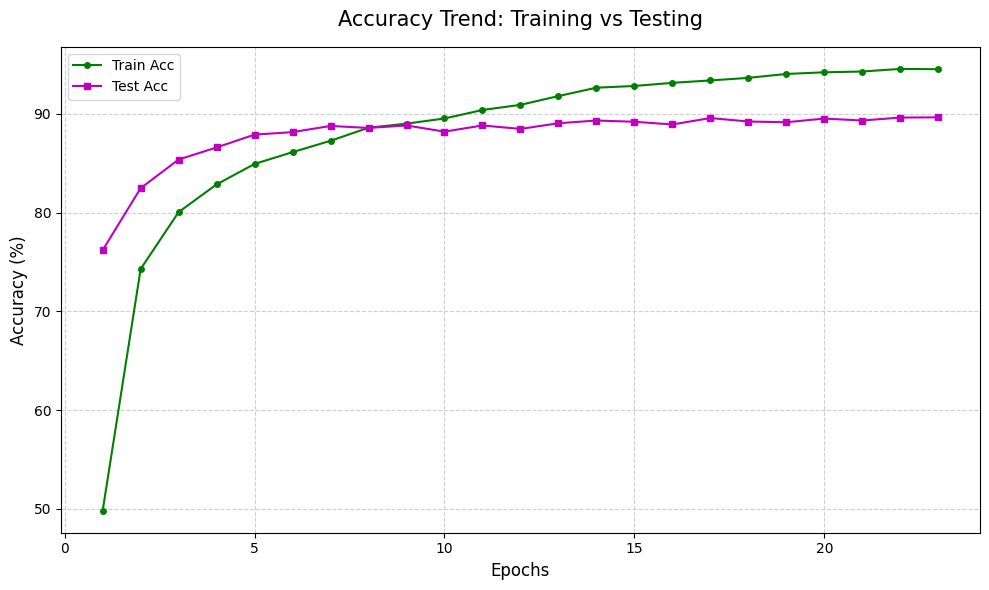

In [56]:
evaluation.plot_accuracy()

##### Loss

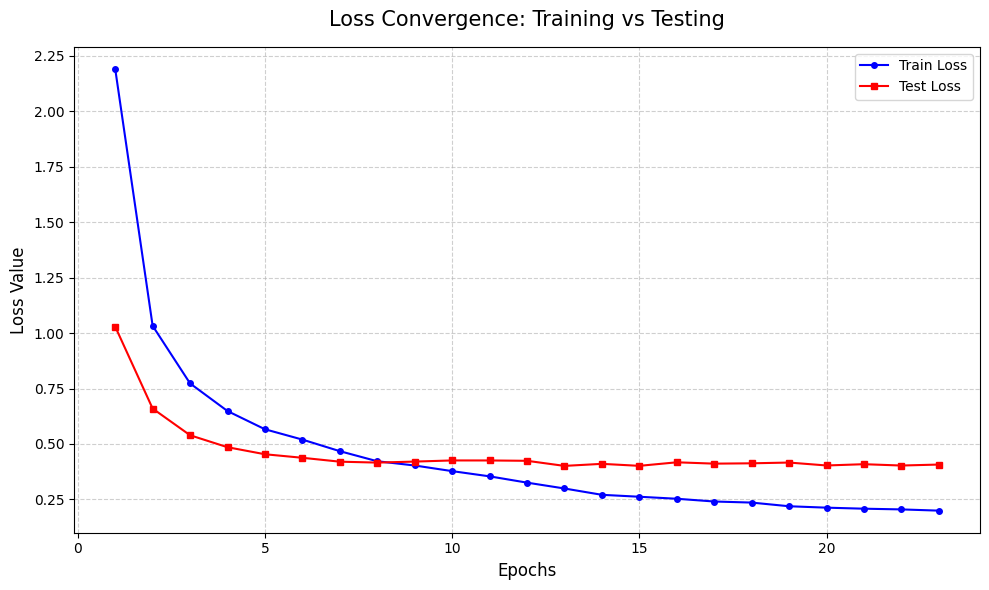

In [57]:
evaluation.plot_loss()

##### f1-score

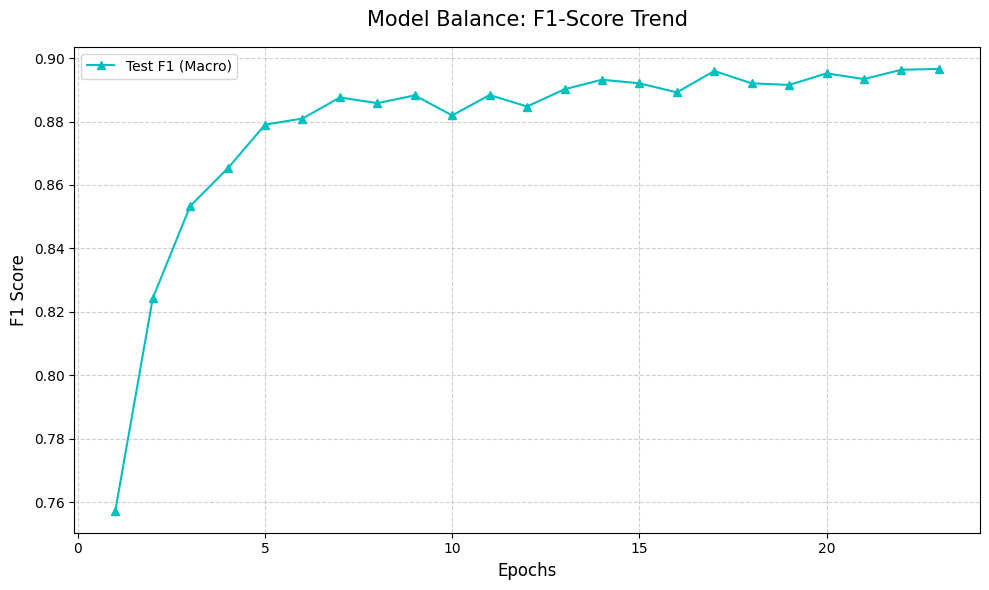

In [58]:
evaluation.plot_f1_score()

##### Learning Rate

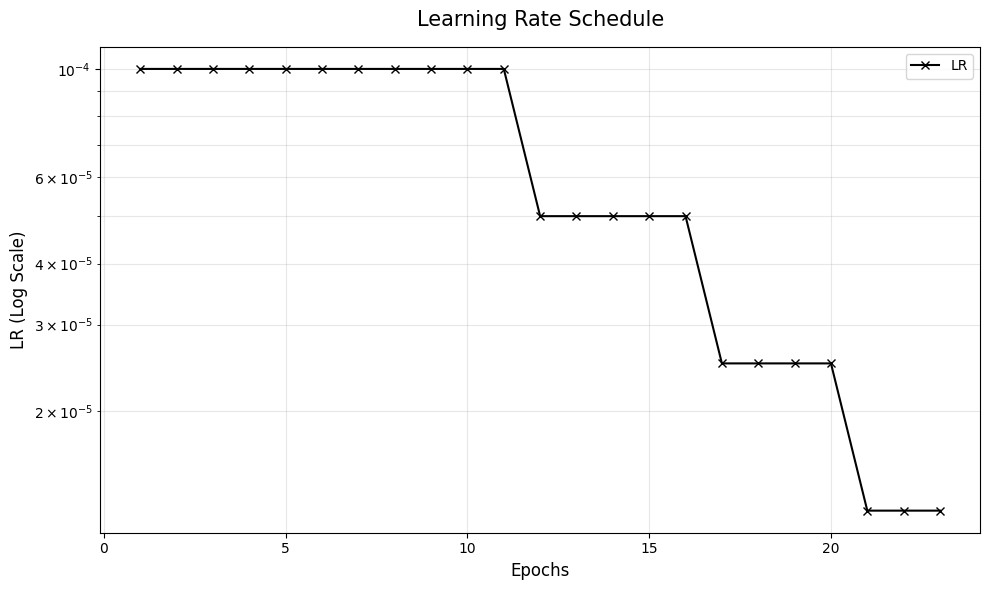

In [59]:
evaluation.plot_learning_rate()

#### Confusion Matrix

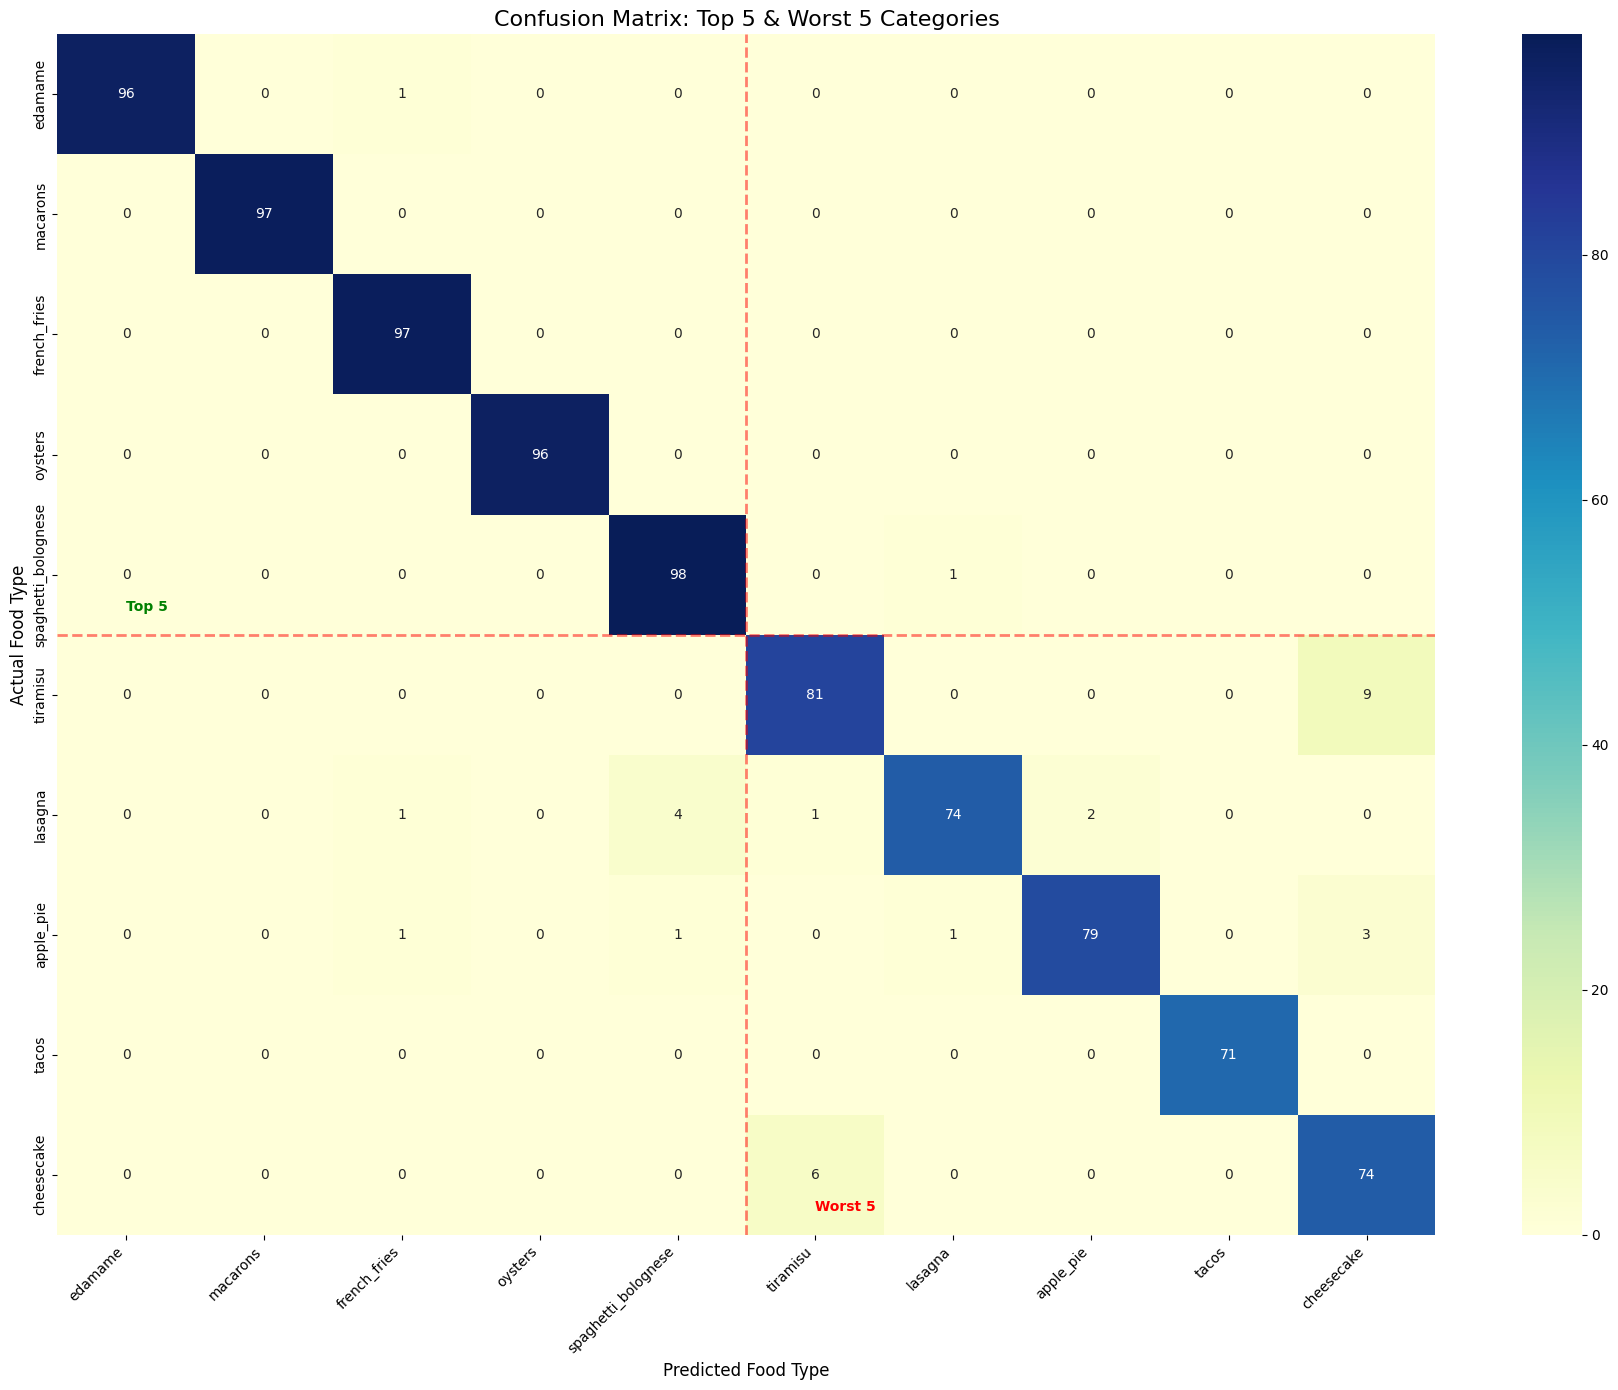

In [63]:
evaluation.plot_confusion_matrix()

#### Detailed Analysis

In [61]:
#Detailed Analysis
evaluation.print_detailed_analysis()


DETAILED CLASSIFICATION PERFORMANCE
Food Class           | F1-Score   | Precision  | Recall    
------------------------------------------------------------
cheesecake           | 0.7590 | 0.7789 | 0.7400
tacos                | 0.7889 | 0.8875 | 0.7100
apple_pie            | 0.7980 | 0.8061 | 0.7900
lasagna              | 0.8177 | 0.9136 | 0.7400
tiramisu             | 0.8182 | 0.8265 | 0.8100

Final Macro F1-Score: 0.8902


### Inference Visualization

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


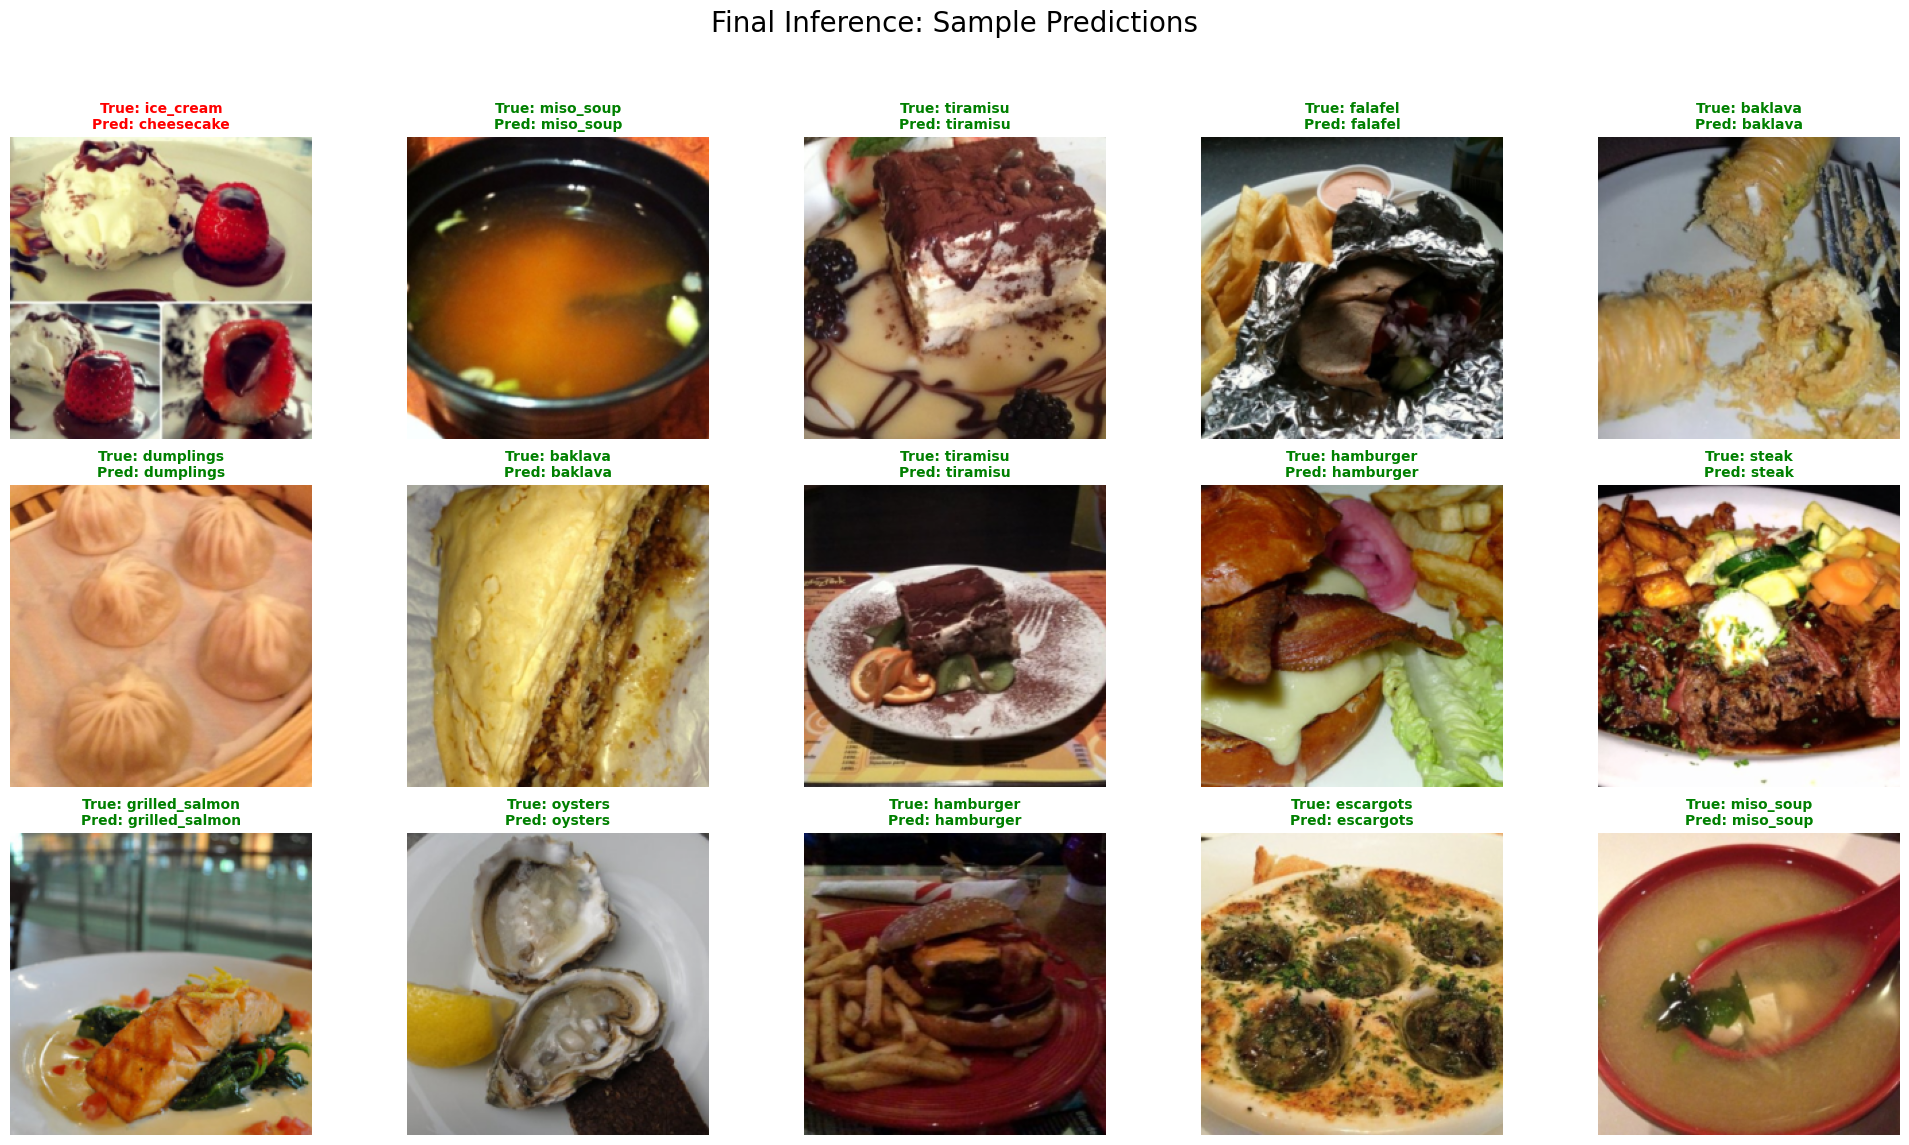

In [62]:
evaluation.visualize_predictions()

## Observation Description

## Conclusion

## Questions to ask AI

* Explain your hyperparameters
* ⁠What is data augmentation
* ⁠Hyper parameter tuning
* ⁠Fine tuning vs. Feature extraction
* ⁠What is patience and how does it work
* ⁠What is resnet model
* ⁠Explain your code, know what’s it is doing